In [2]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from os import getcwd, listdir
import missingno as msno
import re
import plotly.express as px
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
import joblib
from scipy import sparse
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
getcwd()

'C:\\Users\\AmiranBehine.com'

In [4]:
# Portable repository paths are configured above; no local chdir needed.
warnings.filterwarnings("ignore")

In [5]:
df_main=pd.read_csv(DATA_RAW / "divar_real_estate_ads.csv")
df=df_main.copy()

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.0f}'.format)


## inconsistencies </br>
It is seen data inconsistencies in **floor** , **total_floors_count** , **has_balcony** , **extra_person_capacity** columns.</br>
in **floor** there are float and str and negetive number and 30+</br>
in **total_floors_count** there are float and str and **unselect** and 30+ </br>
in **extra_person_capacity** there are float and str and 30+</br>
in **has_balcony** there are 'true', 'false', **'unselect'**, True, False</br>


In [7]:
df = df.replace(
    to_replace=['NA', 'None', '', ' ', 'nan', 'NaN', 'N/A', 'NULL',pd.NA, None],
    value=np.nan
)

#first of all,we replace all unselect value in whole data frame with nan(except title and description):
cols_to_clean = df.columns.difference(['title', 'description'])

df[cols_to_clean] = df[cols_to_clean].replace(
    r'(?i)unselect', 
    np.nan, 
    regex=True
)
print(df.has_balcony.unique())

#has_balcony: replace 'true' and 'false' string with boolean True and False respectively:
df['has_balcony'] = (
    df['has_balcony']
    .str.lower()                     # make 'TRUE', 'True', etc. consistent
    .replace({'true': True, 'false': False})
)


bool_cols = [
    'has_gas', 'has_water', 'has_elevator',
    'has_warehouse', 'has_parking', 'is_rebuilt', 
    'has_electricity', 'has_security_guard', 'has_barbecue',
    'has_pool', 'has_jacuzzi', 'has_sauna'
]
for col in bool_cols:
    if col not in df.columns:
        print(f"Skipping missing column: {col}")
        continue

    # map known patterns → boolean
    df[col] = df[col].map(
        {
            'True': True, 'False': False,
            '1': True, '0': False,
            1: True, 0: False,
            True: True, False: False
        }
    )
    # convert to boolean dtype
    df[col] = df[col].astype('boolean')
    #df[col] = df[col].fillna(False)

    print(f"Column cleaned: {col}")


[nan 'true' 'false' True False]
Column cleaned: has_gas
Column cleaned: has_water
Column cleaned: has_elevator
Column cleaned: has_warehouse
Column cleaned: has_parking
Column cleaned: is_rebuilt
Column cleaned: has_electricity
Column cleaned: has_security_guard
Column cleaned: has_barbecue
Column cleaned: has_pool
Column cleaned: has_jacuzzi
Column cleaned: has_sauna


In [8]:
# floor
df.loc[df['floor'] == '30+', 'floor'] = 31
df['floor'] = pd.to_numeric(df['floor'], errors='coerce').astype('Int64')

# total_floors_count
df.loc[df['total_floors_count'] == '30+', 'total_floors_count'] = 31
df['total_floors_count'] = pd.to_numeric(df['total_floors_count'], errors='coerce').astype('Int64')

# rooms_count
mapping = {
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5,
    'بدون اتاق': 0,
    np.nan: np.nan  # keep NaN as NaN
}
df['rooms_count'] = df['rooms_count'].map(mapping)
df['rooms_count'] = pd.to_numeric(df['rooms_count'], errors='coerce').astype('Int64')

#unit_per_floor
df['unit_per_floor'] = df['unit_per_floor'].replace('more_than_8', 9)# Replace 'more_than_8' with 9
df['unit_per_floor'] = pd.to_numeric(df['unit_per_floor'], errors='coerce')# Convert the rest of the column to numeric (strings → numbers)

# Construction year
def persian_to_english(s):
    if pd.isna(s):
        return s
    persian_digits = '۰۱۲۳۴۵۶۷۸۹'
    english_digits = '0123456789'
    trans_table = str.maketrans(persian_digits, english_digits)
    return str(s).translate(trans_table)

df.loc[df['construction_year'] == 'قبل از ۱۳۷۰', 'construction_year'] = '۱۳۷۰'
df['construction_year'] = df['construction_year'].apply(persian_to_english)
df['construction_year'] = pd.to_numeric(df['construction_year'], errors='coerce').astype('Int64')

# age from construction_year if present
df['age'] = np.where(df['construction_year'].notna(), 1404 - df['construction_year'], np.nan)  # adjust year
df['age'].isna().sum()
df.drop(columns=['construction_year'],inplace=True)

#extra_person_capacity
df.loc[df['extra_person_capacity'] == '30+', 'extra_person_capacity'] = 30
df['extra_person_capacity'] = pd.to_numeric(df['extra_person_capacity'], errors='coerce').astype('Int64')

## check outliers

In [9]:

# remove from data 1111111..., 22222222...., 333333333... ,4444...,5555..,6666...,777777...,8888...,999999999... patterns thar are fake numbers
cols = ['rent_value', 'price_value', 'credit_value', 'transformable_credit','transformed_credit','transformable_rent', 'transformed_rent',
       'rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person']

pattern_anywhere = r'(1{5,}|2{5,}|3{5,}|4{5,}|5{5,}|6{5,}|7{5,}|8{5,}|9{5,})'

for col in cols:
    df[col + '_str'] = df[col].astype('Int64').astype(str)
    df[col + '_str'] = df[col + '_str'].str.replace(r'\.0$', '', regex=True)
    mask = df[col + '_str'].str.contains(pattern_anywhere, na=False)
    df.loc[mask, col] = np.nan
    

df.drop(columns=[c + '_str' for c in cols if (c + '_str') in df.columns],
        inplace=True)

    
df[[
    'rent_value',
    'credit_value',
    'price_value',
    'transformed_credit',
    'transformable_credit',
    'transformed_rent',
    'transformable_rent','rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person'
]].describe()

,rent_value,credit_value,price_value,transformed_credit,transformable_credit,transformed_rent,transformable_rent,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,cost_per_extra_person
count,"341,873","345,134","554,529","72,379","345,124","72,279","341,799","17,743","10,207","13,273","10,048"
mean,"1,081,044,270","9,116,643,639","14,047,848,073","884,786,975","9,116,898,745","16,223,315","1,081,277,589","103,104,925,625","1,160,582,662","15,277,319,944","40,151,583"
std,"318,830,991,707","1,503,133,773,837","450,794,911,398","2,666,853,737","1,503,155,549,713","52,221,980","318,865,503,241","6,806,600,038,238","81,303,572,345","1,738,176,619,818","2,825,759,882"
min,0,0,0,0,0,0,0,0,0,0,0
25%,"400,000","100,000,000","1,500,000,000","200,000,000","100,000,000","1,000,000","400,000","400,000","600,000","580,000","50,000"
50%,"5,000,000","250,000,000","2,900,000,000","400,000,000","250,000,000","6,000,000","5,000,000","800,000","1,200,000","1,100,000","100,000"
75%,"12,000,000","500,000,000","5,950,000,000","850,000,000","500,000,000","15,000,000","12,000,000","1,600,000","2,500,000","2,500,000","200,000"
max,"120,000,000,050,040","500,000,000,000,000","90,000,000,000,000","350,000,000,000","500,000,000,000,000","3,000,000,000","120,000,000,050,040","500,600,700,800,900","5,806,807,801,150","200,250,300,400,450","200,300,400,500"


In [10]:
def has_at_least_6_distinct_digits(x):
    if pd.isna(x):
        return False
    s = str(int(float(x)))  # convert to string safely
    distinct_digits = set([d for d in s if d.isdigit()])
    return len(distinct_digits) >= 6

cols = [
    'rent_value','credit_value','price_value',
    'transformed_credit','transformable_credit',
    'transformed_rent','transformable_rent',
    'rent_price_on_regular_days','rent_price_on_special_days',
    'rent_price_at_weekends','cost_per_extra_person'
]

for c in cols:
    mask = df[c].apply(has_at_least_6_distinct_digits)
    df.loc[mask, c] = np.nan

In [60]:
# we need only upper bound because lower bound must be 0
def cap_values(df, column):
    """
    Caps a numeric column:
        lower bound = 0
        upper bound = 99th percentile
    Replaces values below / above bounds with the bounds.
    """
    upper = df[column].quantile(0.99)
    
    df[column] = df[column].clip(lower=0, upper=upper)
    return df

columns_to_cap = [
    'rent_value', 'credit_value', 'price_value',
    'transformed_credit', 'transformed_rent','rent_price_on_regular_days','rent_price_on_special_days','rent_price_at_weekends','cost_per_extra_person'
]

for col in columns_to_cap:
    if col in df.columns:
        df = cap_values(df, col)

df[columns_to_cap].describe()

,rent_value,credit_value,price_value,transformed_credit,transformed_rent,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,cost_per_extra_person
count,"341,541","344,851","553,059","72,379","72,277","17,732","10,201","13,266","10,043"
mean,"8,563,099","357,618,377","4,239,973,347","609,307,817","9,639,745","1,058,798","1,611,963","1,544,684","131,238"
std,"9,710,699","315,477,309","3,711,219,895","501,773,938","10,494,485","848,628","1,315,541","1,241,857","103,459"
min,0,0,0,0,0,0,0,0,0
25%,"400,000","100,000,000","1,500,000,000","200,000,000","1,000,000","400,000","600,000","580,000","50,000"
50%,"5,000,000","250,000,000","2,900,000,000","400,000,000","6,000,000","800,000","1,200,000","1,100,000","100,000"
75%,"12,000,000","500,000,000","5,945,000,000","850,000,000","15,000,000","1,600,000","2,500,000","2,500,000","200,000"
max,"30,000,000","1,000,000,000","12,306,400,000","1,700,000,000","32,000,000","2,600,000","4,000,000","3,800,000","300,000"


In [26]:
# this is need for text proccessing
mask_title_len1 = df['title'].astype(str).str.len() == 1
mask_desc_len1  = df['description'].astype(str).str.len() == 1

# Rows where both title and description have length 1
mask_both_len1 = mask_title_len1 & mask_desc_len1

# View the problematic rows
df[mask_both_len1]


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
52251,residential-sell,apartment-sell,tehran,east-tehranpars,2024-08-01 00:00:00,NaN,پ,پ,NaN,NaN,NaN,NaN,مقطوع,"1,616",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300,NaN,NaN,1,3,<NA>,NaN,NaN,True,False,True,1403,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stone,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,36,52,NaN
393040,residential-rent,house-villa-rent,pool,NaN,2024-06-01 00:00:00,NaN,پ,پ,مقطوع,"1,500,000",NaN,NaN,NaN,NaN,مقطوع,"10,000,000",False,False,"10,000,000",NaN,"1,500,000",NaN,161,161,NaN,NaN,<NA>,1,<NA>,NaN,True,NaN,True,False,1387,False,True,NaN,True,True,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,36,51,NaN


# Missing Values

In [11]:
df['cat3_slug'] = df['cat3_slug'].fillna('office_rent')


In [12]:
# fill columns about floor with 1 or 0 in not apartments
# Define categories that should NOT be filled with 1
excluded_categories = [
    'apartment-sell', 'apartment-rent',
    'partnership', 'presell','plot-old'
]

# Create mask for rows where cat3_slug is NOT in excluded categories
mask = ~df['cat3_slug'].isin(excluded_categories)

# Fill NaN only in those rows, only for specific columns
df.loc[mask, ['floor', 'total_floors_count','unit_per_floor']] = (
    df.loc[mask, ['floor', 'total_floors_count','unit_per_floor']].fillna(1)
)
df.loc[(df['cat3_slug']=='plot-old'), ['floor', 'total_floors_count','unit_per_floor']] = (
    df.loc[mask, ['floor', 'total_floors_count','unit_per_floor']]
    .fillna(0)
)

In [13]:
#for rows that bothe of building_size and land_size are NAN, search the title and description and
# if there is 'meter' word in them,if also there is one of the keywords_land words and there isnt any of exclude_words,it must be 
# the land_size and the building_size must be zero,and else it is building size.
df_before = df.copy()
print(df[df['building_size'].isna() & df['land_size'].isna()].shape)

keywords_land = ['زمین', 'باغچه', 'چهاردیواری', 'باغ']
exclude_words = ['بنا', 'زیربنا', 'ویو', 'تهاتر', 'تعویض']  # example exclude words

def extract_number(text):
    """Extracts the last number before/after 'متر' in the text."""
    match = re.search(r'(\d+)\s*متر', text)
    return int(match.group(1)) if match else np.nan

def impute_sizes(row):
    if pd.isna(row['building_size']) and pd.isna(row['land_size']):
        # Check both title and description
        for col in ['title', 'description']:
            text = row[col]
            if isinstance(text, str) and 'متر' in text:
                num = extract_number(text)
                if not np.isnan(num):
                    if any(k in text for k in keywords_land) and not any(e in text for e in exclude_words):
                        row['land_size'] = num
                    else:
                        row['building_size'] = num
                    return row
    return row

df[['building_size', 'land_size']] = df.apply(impute_sizes, axis=1)[['building_size', 'land_size']]

print(df[df['building_size'].isna() & df['land_size'].isna()].shape)


(19606, 60)
(5985, 60)


In [14]:
#land_size for apartments must be 0 not NAN.because in dropna we lose them.
# Define the property types
apartment_types = ['apartment-sell', 'apartment-rent', 'suite-apartment']

# Fill NaN land_size with 0 for these rows
df.loc[df['cat3_slug'].isin(apartment_types), 'land_size'] =df.loc[df['cat3_slug'].isin(apartment_types), 'land_size'].fillna(0)


In [15]:
#some plot-olds that must have only land_size,they have only building size,we swap land_size and building_size and fill building_size with zero
df_before=df.copy()
# Apply your existing mask
words_include = ['زمین', 'باغچه', 'چهاردیواری', 'باغ']
words_exclude = ['بنا', 'زیربنا','ویو','تهاتر','تعویض']

mask = (
    (df['building_size'].notna()) &
    (df['building_size'] > 0) &
    (df['land_size'].isna()) &
    (df['cat3_slug'] == 'plot-old') &
    (
        df['description'].fillna('').str.contains('|'.join(words_include), na=False) |
        df['title'].fillna('').str.contains('|'.join(words_include), na=False)
    ) &
    ~(
        df['description'].fillna('').str.contains('|'.join(words_exclude), na=False) |
        df['title'].fillna('').str.contains('|'.join(words_exclude), na=False)
    )
)

# Swap: Move building_size → land_size
df.loc[mask, 'land_size'] = df.loc[mask, 'building_size']

# Set building_size = 0 for those rows
df.loc[mask, 'building_size'] = 0


#df_filtered = df.loc[mask, ['cat3_slug','title', 'description', 'building_size', 'land_size','price_value']]
##df_filtered.head(10)


In [66]:
#there are alot of price values of 1.we cut them.
print(df.shape)
df = df[(df['price_value'] != 1)&(df['rent_value'] != 1)&(df['credit_value'] != 1)]
print(df.shape)

(1000000, 54)
(999545, 54)


In [16]:
#remove building_size and land_sizes that are NAN or 1
df = df[
    ~((df['building_size'] == 1) &
    (df['land_size'] == 1)) &
    ~(df['building_size'].isna() & (df['land_size'] == 1)) &
    ~((df['building_size'] == 1) & df['land_size'].isna()) &
    ~((df['building_size'].isna())  & (df['land_size'].isna()))
].copy()
df.shape

(993554, 60)

In [17]:
#there is only two city_slug that is NAN.so drop them
valid_types = (str)   # expected type
col = "city_slug"

# mask for rows that are NOT valid
mask_unusual = ~df[col].map(lambda x: isinstance(x, valid_types))

# view unusual rows
df_unusual = df[mask_unusual]
print(df_unusual[[col]])

# drop the unusual rows from the original DataFrame
df = df[~mask_unusual]
df.dropna(subset=["city_slug"],inplace=True)

# check
print(df[col].dtype)
print(df.shape)


       city_slug
292674       NaN
676502       NaN
object
(993552, 60)


In [30]:
#check inconsistency in neighborhood_slug

valid_types = (str)   # you can change this
col = "neighborhood_slug"
mask_unusual = ~df[col].map(lambda x: isinstance(x, valid_types))
df_unusual = df[mask_unusual].dropna()
print(df_unusual[[col]])     # only the problematic column
#print(df_unusual)            # full rows


Empty DataFrame
Columns: [neighborhood_slug]
Index: []


In [18]:
#try to find user_type from description and impute this column where it is NAN
print(f"before:{df["user_type"].isna().mean() * 100}")
#my_df[my_df["user_type"].notna()]
def user_type_filling(row):
    if pd.isna(row["user_type"]):
        desc = str(row["description"])  # اگه خالی بود، خطا نده
        if "املاک" in desc or "گروه" in desc or "مهندس" in desc or "هلدینگ" in desc or "کد" in desc or "کارشناس" in desc or "مشاور" in desc:
            return "مشاور املاک"
        elif "مالک" in desc or "بدون واسطه" in desc:
            return "شخصی"
    return row["user_type"]
df["user_type"] = df.apply(user_type_filling, axis=1)
#my_df["user_type"] = df["user_type"]

print(f"after:{df["user_type"].isna().mean() * 100}")

before:71.05013124627598
after:47.05460811311335


# تحلیل بازار املاک ایران

در این یک میلیون رکورد، تعداد آگهی های شهر تهران، بیشتر از همه، و بیش از دوبرابر شهر های دیگر است .پس از آن به ترتیب: مشهد، ، کرج، شیراز، اصفهان، تبریزو..قراردارند.، .

Text(0.5, 1.0, 'Number of flats in location')

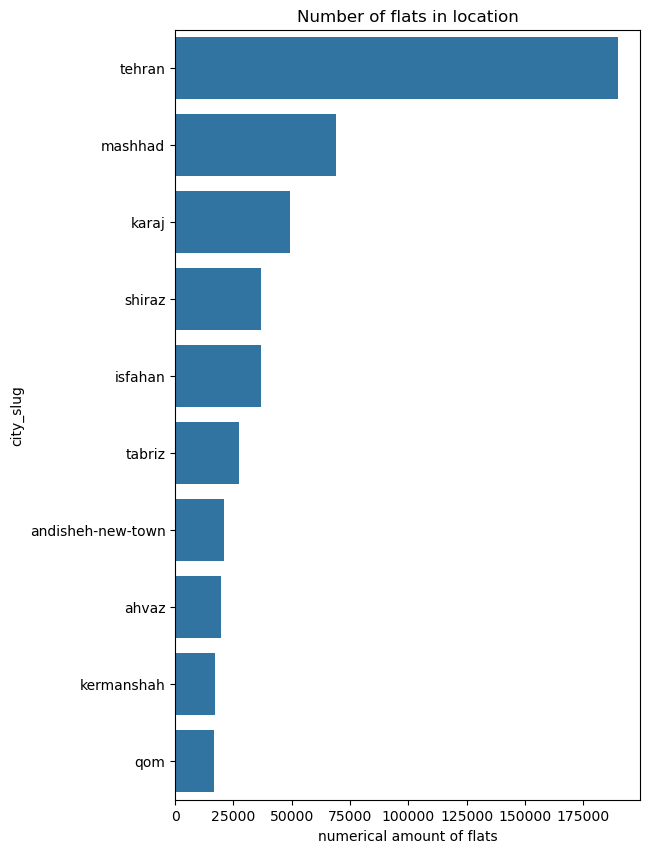

In [37]:
df3 = df['city_slug'].value_counts().copy()
df3 = df3[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df3.values, y=df3.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در بخش آگهی های فروش مسکونی، بیشتر آگهی ها مربوط به فروش آپارتمان است.

Text(0.5, 1.0, 'Number of flats in location')

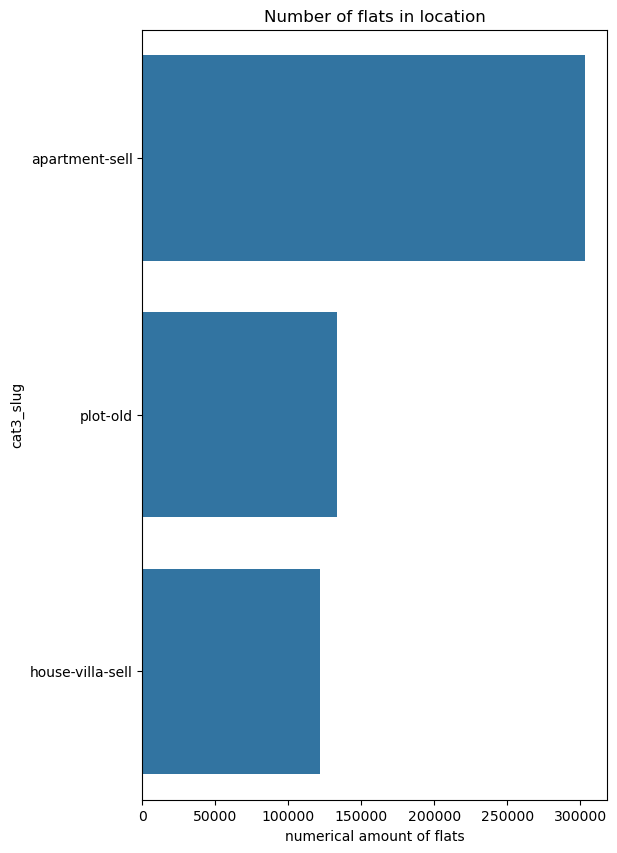

In [72]:
df4 = df[(df['cat2_slug']=='residential-sell')].cat3_slug.value_counts().copy()

fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df4.values, y=df4.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

پس چون بیشتر شهر تهران آگهی ثبت کرده سراغ این شهر می رویم و میبینیم اینجا هم بیشتر آگهی ها مربوط به فروش آپارتمان است . بعد از آن زمین و ملک کلنگی و سپس فروش خانه ویلایی وجود دارد.

Text(0.5, 1.0, 'Number of flats in location')

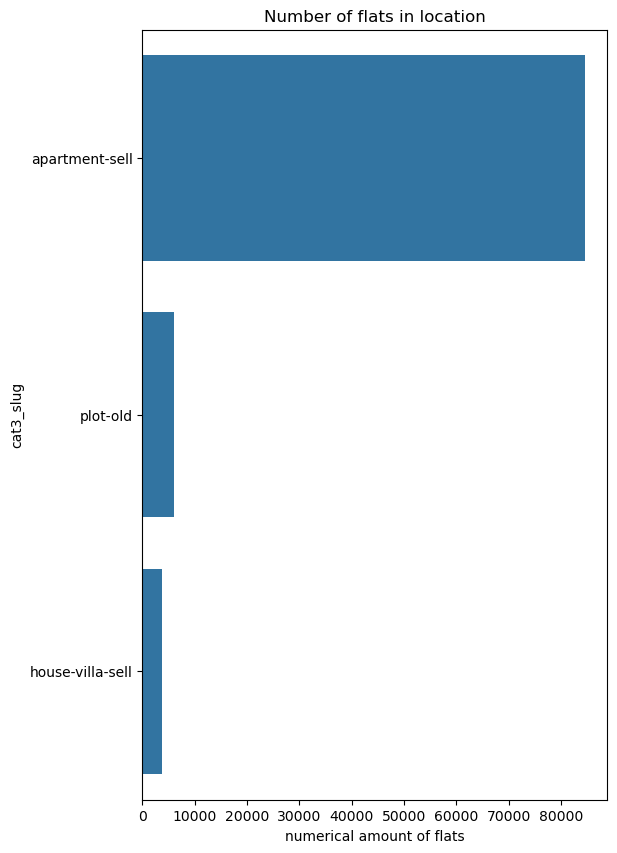

In [39]:
df4 = df[(df['city_slug']=='tehran')&(df['cat2_slug']=='residential-sell')].cat3_slug.value_counts().copy()

fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df4.values, y=df4.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

می بینیم که در شهر تهران، به ترتیب محله های پونک، جیحون، سلسبیل،، دریاچه چیتگر و... بیشتر آگهی ثبت شده دارند .

Text(0.5, 1.0, 'Number of flats in location')

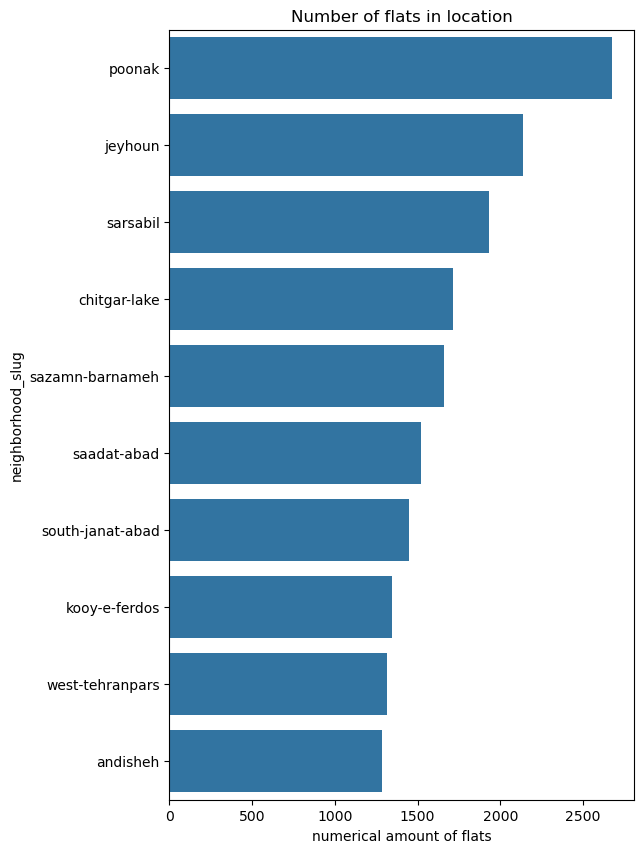

In [40]:
df5 = df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')].neighborhood_slug.value_counts().copy()
df5 = df5[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df5.values, y=df5.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

میبینیم که در شوش و سپس در شهرک غرب، خانه های ویلایی بالای 20 سال ساختی که نوسازی نشده اند، بیشتر وجود دارد. 

Text(0.5, 1.0, 'Number of flats in location')

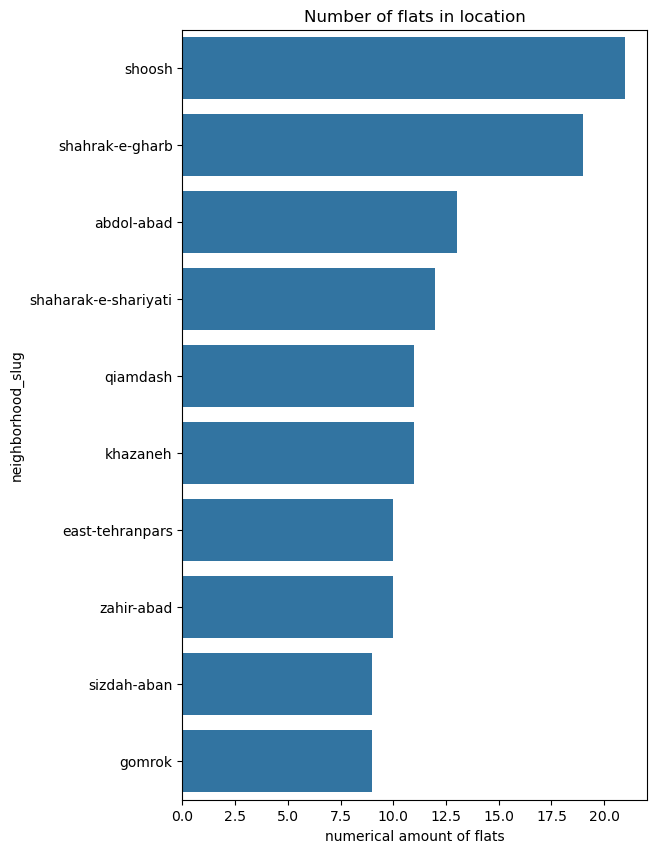

In [51]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='house-villa-sell')&(df['age']>20) &(df['is_rebuilt']==False)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در محله جیحون و سلسبیل نیز آپارتمان هایی که نوسازی نشده اند و قدیمی هستند وجود دارد.

Text(0.5, 1.0, 'Number of flats in location')

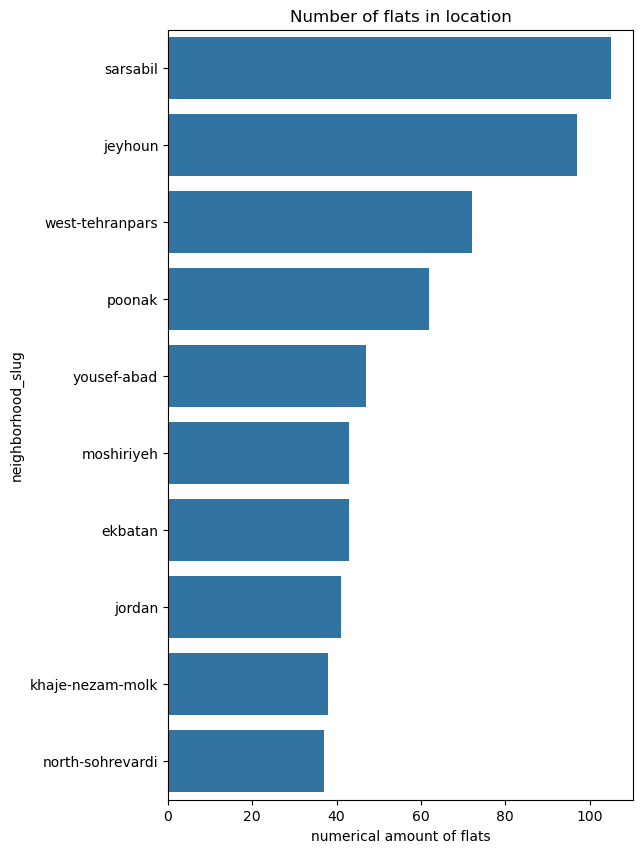

In [73]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']>20) 
&(df['is_rebuilt']==False)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در محله های سلسبیل و جیحون نرخ خانه های بازسازی شده نیز بیشتر است.

Text(0.5, 1.0, 'Number of flats in location')

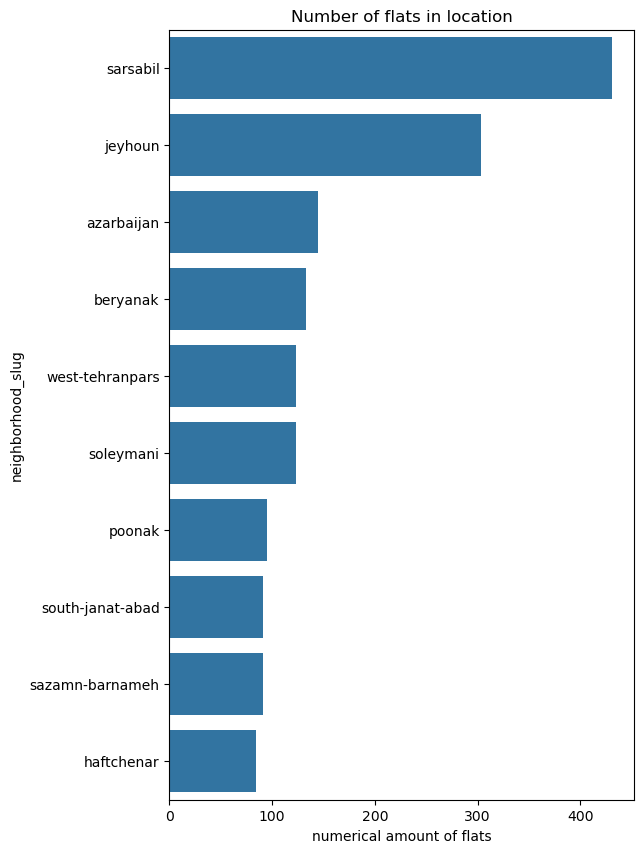

In [74]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']>20) 
&(df['is_rebuilt']==True)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در محله های الهیه و زعفرانیه، آپارتمان های بزرگ با بیش از 3 خواب،بیشتر از بقیه محله ها وجود دارد.

Text(0.5, 1.0, 'Number of flats in location')

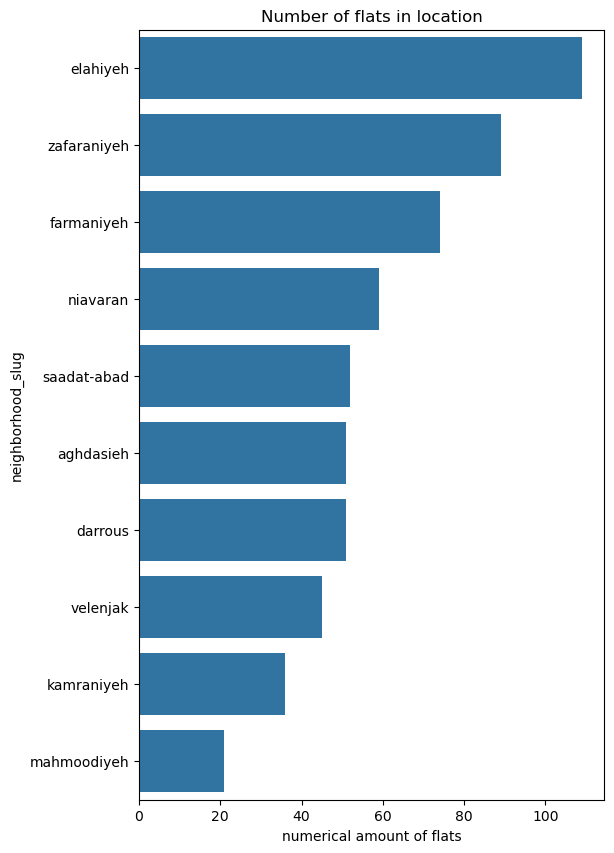

In [52]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['rooms_count']>=3)
&(df['building_size']>=300)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در تهرانپارس و سعادت آباد و شهرک گلستان خانه های ویلایی نوساز و بزرگ، بیشتر از بقیه محله ها وجود دارد.

Text(0.5, 1.0, 'Number of flats in location')

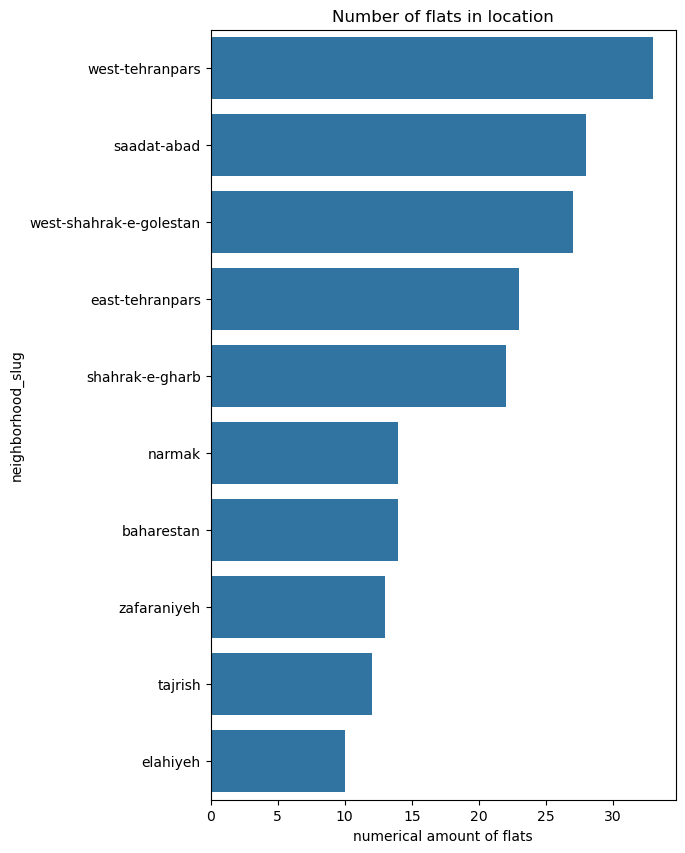

In [76]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='house-villa-sell')&(df['rooms_count']>=3)
&(df['land_size']>=300)&(df['age']<5)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در شهرک غرب خانه های ویلایی قدیمی بیشتر از بقیه محله ها وجود دارد.

Text(0.5, 1.0, 'Number of flats in location')

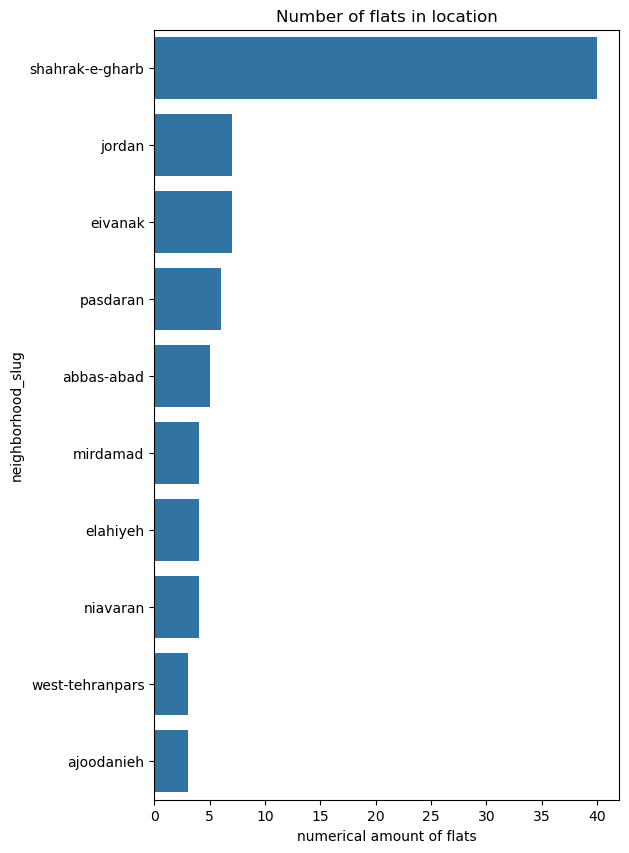

In [59]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='house-villa-sell')&(df['rooms_count']>=3)
&(df['land_size']>=300)&(df['age']>=25)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در این یک میلیون آگهی، بیشتر خانه های استخردار و جکوزی و سونا در شمال کشور قرار دارند.

Text(0.5, 1.0, 'Number of flats in location')

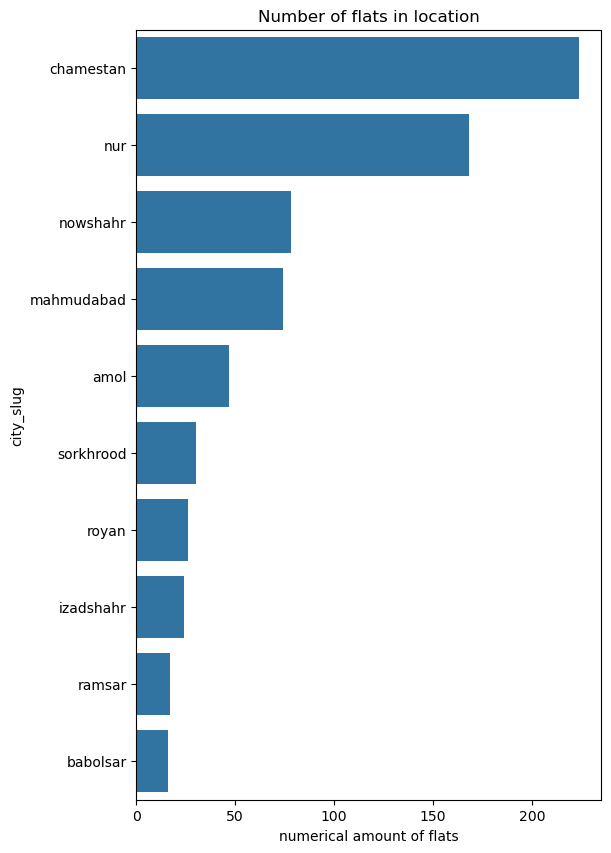

In [67]:
df6= df[(df['cat3_slug']=='house-villa-sell')&(df['has_jacuzzi']==True)&(df['has_sauna']==True)
&(df['has_pool']==True)].city_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

Text(0.5, 1.0, 'Number of flats in location')

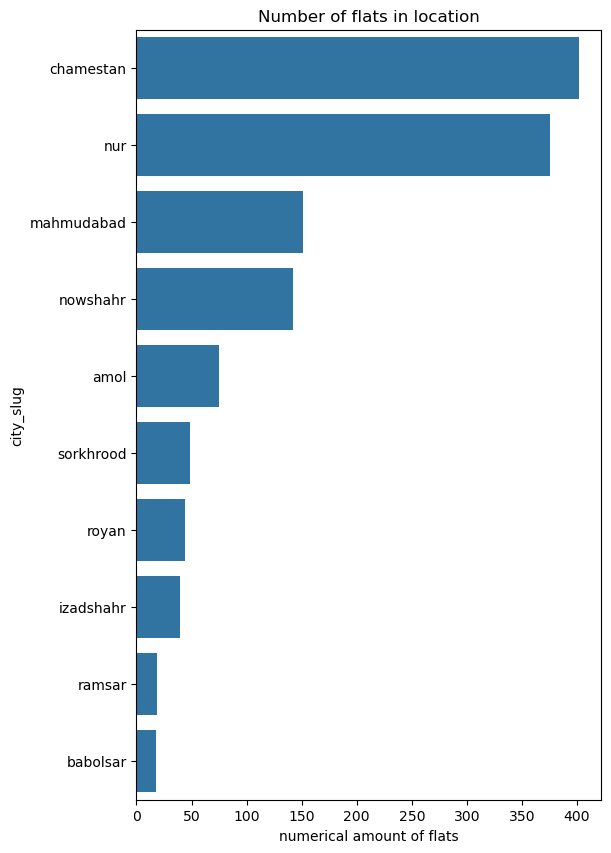

In [70]:
df6= df[(df['cat3_slug']=='house-villa-sell')&(df['has_security_guard']==True)&(df['rooms_count']>=3)
&(df['has_pool']==True)].city_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

آپارتمان های نوساز تهران بیشتر در محدوده دریاچه چیتگر قرار دارند.

Text(0.5, 1.0, 'Number of flats in location')

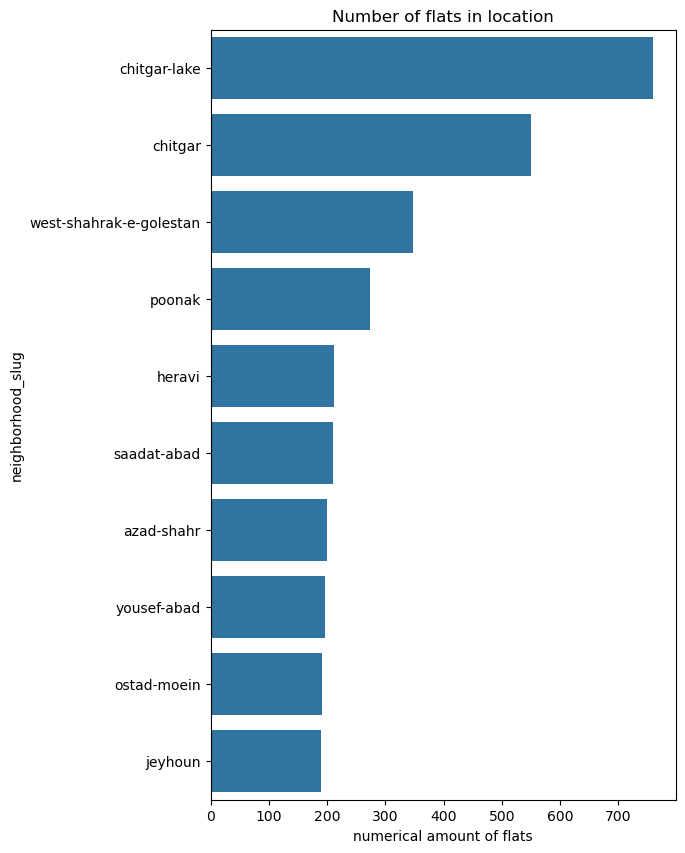

In [44]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']<=1)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در تهران بیشتر آپارتمان های نوساز زیر 85 متر د محدوده دریاچه چیتگر قرار دارد.

Text(0.5, 1.0, 'Number of flats in location')

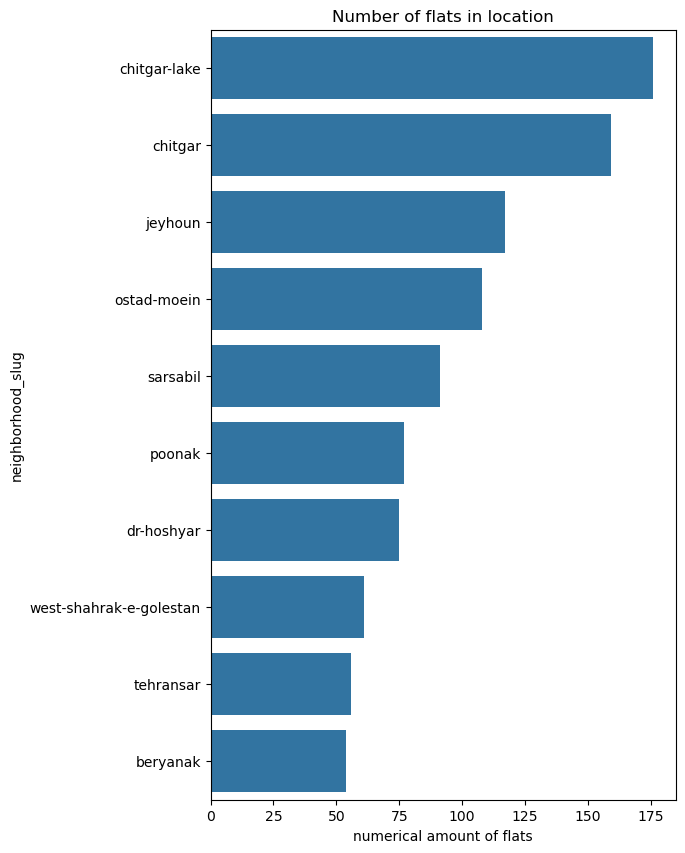

In [77]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']<=1)
&(df['building_size']<=85)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

در تهران، آپارتمان های نوساز با امکانات آسانسور و انباری و پارکینگ در محدوده دریاچه چیتگر، بیشتر وجود دارند.

Text(0.5, 1.0, 'Number of flats in location')

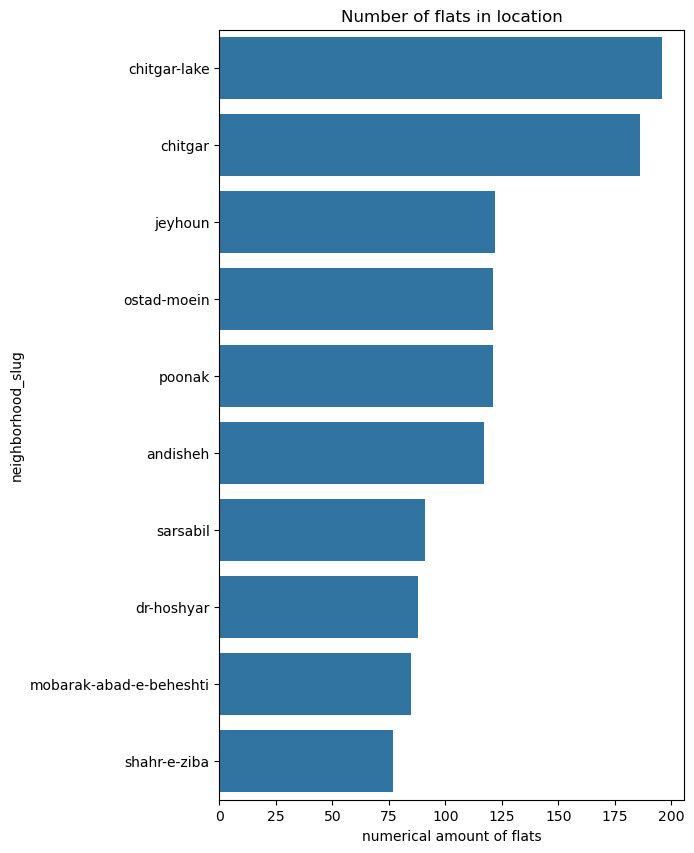

In [78]:
df6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']<=3)
&(df['building_size']<=85)&(df['has_elevator']==True)&(df['has_parking']==True)&(df['has_warehouse']==True)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

آپارتمان های ارزان قیمت با امکانات آسانسور و پارکینگ و انباری بیشتر در محدوده دریاچه چیتگر وجود دارند

Text(0.5, 1.0, 'Number of flats in location')

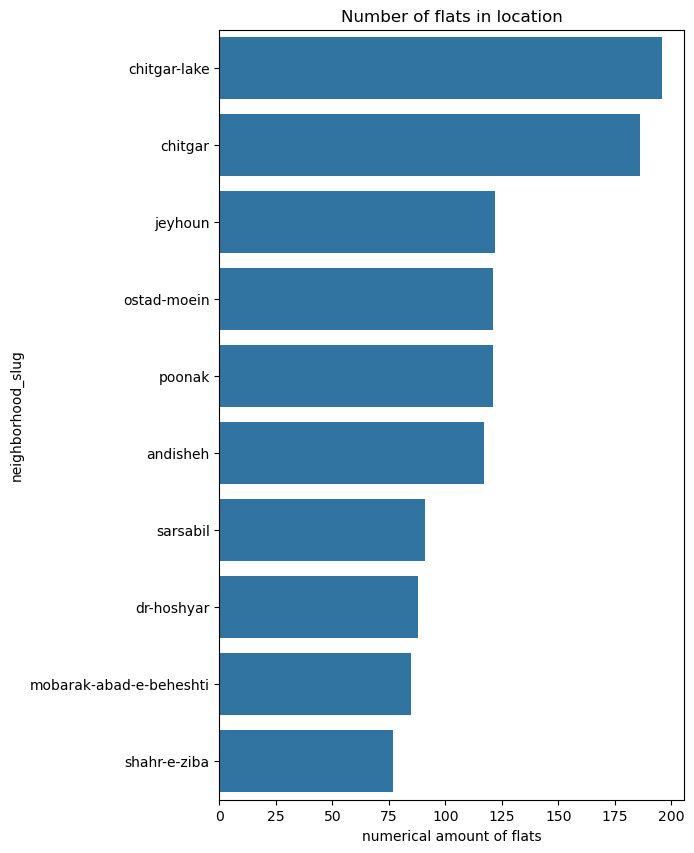

In [89]:
mean_price=(df_sell[(df_sell['cat3_slug']=='apartment-sell')&
            (df_sell['city_slug']=='tehran')]).groupby( 'neighborhood_slug' )['price_value'].mean().sort_values()[0]
mean_pricedf6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']<=3)&(df['price_value']<=mean_price)
&(df['building_size']<=85)&(df['has_elevator']==True)&(df['has_parking']==True)&(df['has_warehouse']==True)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

Text(0.5, 1.0, 'Number of flats in location')

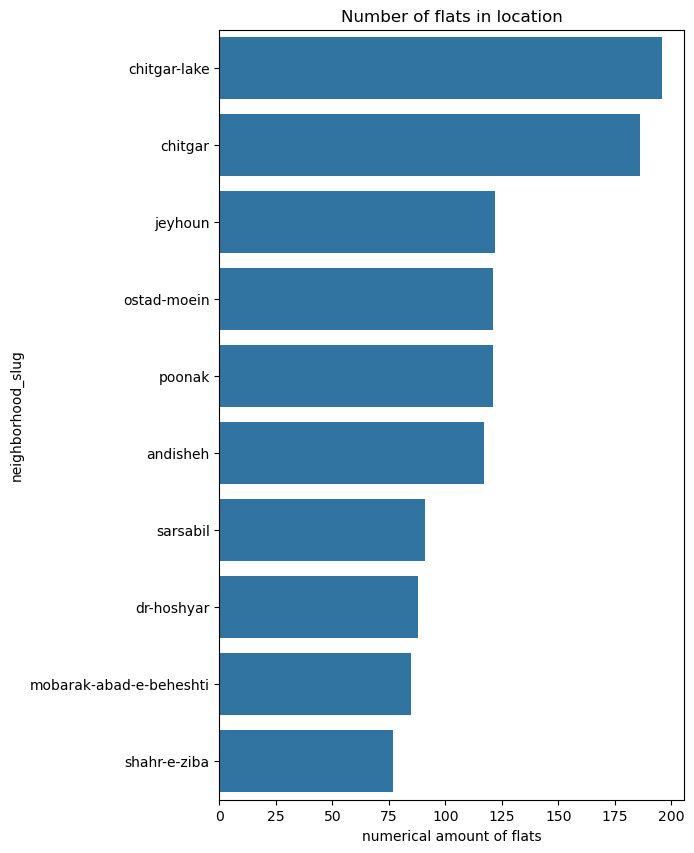

In [90]:
mean_price=(df_sell[(df_sell['cat3_slug']=='apartment-sell')&
            (df_sell['city_slug']=='tehran')]).groupby( 'neighborhood_slug' )['price_value'].mean().sort_values()[0]
mean_pricedf6= df[(df['city_slug']=='tehran')&(df['cat3_slug']=='apartment-sell')&(df['age']<=3)&(df['price_value']<=mean_price)
&(df['building_size']<=85)&(df['has_elevator']==True)&(df['has_parking']==True)&(df['has_warehouse']==True)&(df['total_floors_count'] <= 5)].neighborhood_slug.value_counts().copy()
df6 = df6[:10]
fig, ax = plt.subplots(figsize=(6,10))
sns.barplot(x=df6.values, y=df6.index,ax=ax)
plt.xlabel('numerical amount of flats')
plt.title('Number of flats in location')

In [81]:
(df_sell[df_sell['cat3_slug']=='apartment-sell']).groupby( 'city_slug' )['price_value'].mean().sort_values(ascending=False)

city_slug
lar             139,083,393,939
shahedshahr      59,135,588,565
tehran           31,583,163,214
minoodasht       31,530,034,552
nowshahr         26,269,237,116
                      ...      
hormuz               15,000,000
mazrae-katool         1,400,000
arjmand                       1
negin-shahr                   0
ghorogh                     NaN
Name: price_value, Length: 383, dtype: float64

In [34]:
(df_sell[df_sell['cat3_slug']=='house-villa-sell']).groupby( 'city_slug' )['price_value'].mean().sort_values(ascending=False)

city_slug
eqbaliyeh        252,830,481,565
lavasan-city     203,167,094,596
deylaman         202,797,066,667
damghan           81,634,842,117
aran-va-bidgol    80,861,127,456
                       ...      
anbaralum            850,000,000
mohr                 445,000,000
qasemabad-khaf       403,666,917
maraveh-tapeh                NaN
yanghagh                     NaN
Name: price_value, Length: 416, dtype: float64

In [33]:
(df_sell[df_sell['cat3_slug']=='plot-old']).groupby( 'city_slug' )['price_value'].mean().sort_values(ascending=False)

city_slug
maku             501,602,742,841
maraveh-tapeh    450,525,000,000
jahrom           261,357,765,714
qarchak-city     189,087,857,565
mehran           167,466,000,000
                       ...      
taybad               319,828,571
qasemabad-khaf       300,000,000
anbaralum                    NaN
khoour                       NaN
yanghagh                     NaN
Name: price_value, Length: 421, dtype: float64

In [189]:
df_sell.groupby(['city_slug','neighborhood_slug'])['price_value'].mean().sort_values(ascending=False).reset_index()

,city_slug,neighborhood_slug,price_value
0,tehran,jamaran,"1,936,395,426,829"
1,tehran,hezarsang,"1,769,860,555,556"
2,shiraz,shahrak-bahonar,"1,076,721,714,286"
3,tehran,darband,"496,131,457,159"
4,tehran,aghdasieh,"407,923,079,152"
...,...,...,...
1170,rasht,kuy-qods,"1,120,000,000"
1171,mashhad,arvand,"1,119,392,941"
1172,mashhad,mahdiabad,"1,089,174,618"
1173,rasht,shahrak-sanaati,"720,000,000"
